<a href="https://colab.research.google.com/github/Prudhvilakshman1112/GEN-AI/blob/main/EXP_9_Multimodal_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Cell 1: Environment Setup and Library Installation
In this cell, we install the Hugging Face transformers library. We then import torch for computation and PIL for image processing. We also initialize the BLIP Processor (which prepares images for the model) and the BLIP Model itself.

In [ ]:
# Install the transformers library
!pip install transformers -q

import torch
import requests
from PIL import Image, UnidentifiedImageError
from io import BytesIO
import matplotlib.pyplot as plt
from transformers import BlipProcessor, BlipForConditionalGeneration

# Setup device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load the BLIP processor and model
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

print(f"BLIP model loaded successfully on {device}!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

BLIP model loaded successfully on cpu!


#Cell 2: Image Fetching and Processing
Here, we define the image URLs we want to describe. The script uses the requests library to download the images and PIL to convert them into a format the model can read. We use a try-except block to handle any potential network errors or invalid image formats gracefully.

In [ ]:
# Image URLs to process
image_urls = [
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSKE8h_W0j8X-oxeLDd65GyNXJGKgaf61NoNg&s"
]

images_list = []
print("Fetching images...")

# Prepare list for processing
for url in image_urls:
    try:
        response = requests.get(url)
        response.raise_for_status()
        image = Image.open(BytesIO(response.content)).convert("RGB")
        images_list.append(image)
    except Exception as e:
        print(f"Error fetching image: {e}")

print(f"Successfully loaded {len(images_list)} images.")

Fetching images...
Successfully loaded 1 images.


#Cell 3: Generating Captions via Inference
This cell performs the "Inference." The processor converts the image into pixels, and the model uses a technique called Beam Search (num_beams=5) to find the most accurate and descriptive sentence for each image. The numerical output is then "decoded" back into human-readable English.

In [ ]:
captions_list = []
print("=== Generating Captions ===")

for i, image in enumerate(images_list):
    # Preprocess the image
    inputs = processor(image, return_tensors="pt").to(device)

    # Generate the caption
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=50,
            num_beams=5,
            early_stopping=True
        )

    # Decode numerical output to text
    caption = processor.decode(output[0], skip_special_tokens=True)
    captions_list.append(caption)
    print(f"Image {i+1}: {caption}")

=== Generating Captions ===
Image 1: a tiger sitting on top of a rock


#Cell 4: Visualizing Results
Finally, we use matplotlib to display the original images alongside the AI-generated captions. This allows us to visually verify how well the model understood the context of the photographs.


Displaying results:


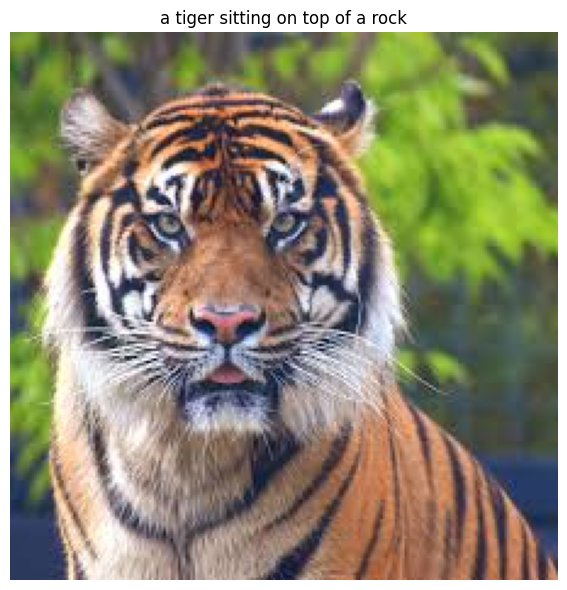

In [ ]:
# Display images with their generated captions
print("\nDisplaying results:")
num_images = len(images_list)
fig, axes = plt.subplots(1, max(1, num_images), figsize=(12, 6))

# Handle single image or multiple image plot indexing
if num_images == 1:
    axes.imshow(images_list[0])
    axes.set_title(captions_list[0], wrap=True)
    axes.axis('off')
else:
    for i, (img, cap) in enumerate(zip(images_list, captions_list)):
        axes[i].imshow(img)
        axes[i].set_title(cap, wrap=True)
        axes[i].axis('off')

plt.tight_layout()
plt.show()